# 1. EDA

Loading the Auto MPG dataset to get started.

In [345]:
import pandas as pd

# Auto MPG dataset from the UCI Machine Learning Repository.
# Served over plain http to avoid macOS SSL cert verification issues.
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

column_names = [
    "mpg", "cylinders", "displacement", "horsepower", "weight",
    "acceleration", "model_year", "origin", "car_name",
]

# The file is whitespace-delimited, has no header, and uses '?' for missing values.
df = pd.read_csv(
    url,
    names=column_names,
    sep=r"\s+",
    na_values="?",
)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [346]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


In [347]:
# Smartly impute missing horsepower values.
# Horsepower is strongly tied to engine size, so instead of a single global
# mean/median we fill each gap with the median horsepower of cars that share
# the same cylinder count.
print("Missing horsepower before:", df["horsepower"].isna().sum())

df["horsepower"] = df["horsepower"].fillna(
    df.groupby("cylinders")["horsepower"].transform("median")
)

print("Missing horsepower after: ", df["horsepower"].isna().sum())

Missing horsepower before: 6
Missing horsepower after:  0


In [348]:
# One-hot encode the origin column (1=USA, 2=Europe, 3=Japan)
df["origin"] = df["origin"].map({1: "usa", 2: "europe", 3: "japan"})
df = pd.get_dummies(df, columns=["origin"], prefix="origin")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,car_name,origin_europe,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504.0,12.0,70,chevrolet chevelle malibu,False,False,True
1,15.0,8,350.0,165.0,3693.0,11.5,70,buick skylark 320,False,False,True
2,18.0,8,318.0,150.0,3436.0,11.0,70,plymouth satellite,False,False,True
3,16.0,8,304.0,150.0,3433.0,12.0,70,amc rebel sst,False,False,True
4,17.0,8,302.0,140.0,3449.0,10.5,70,ford torino,False,False,True


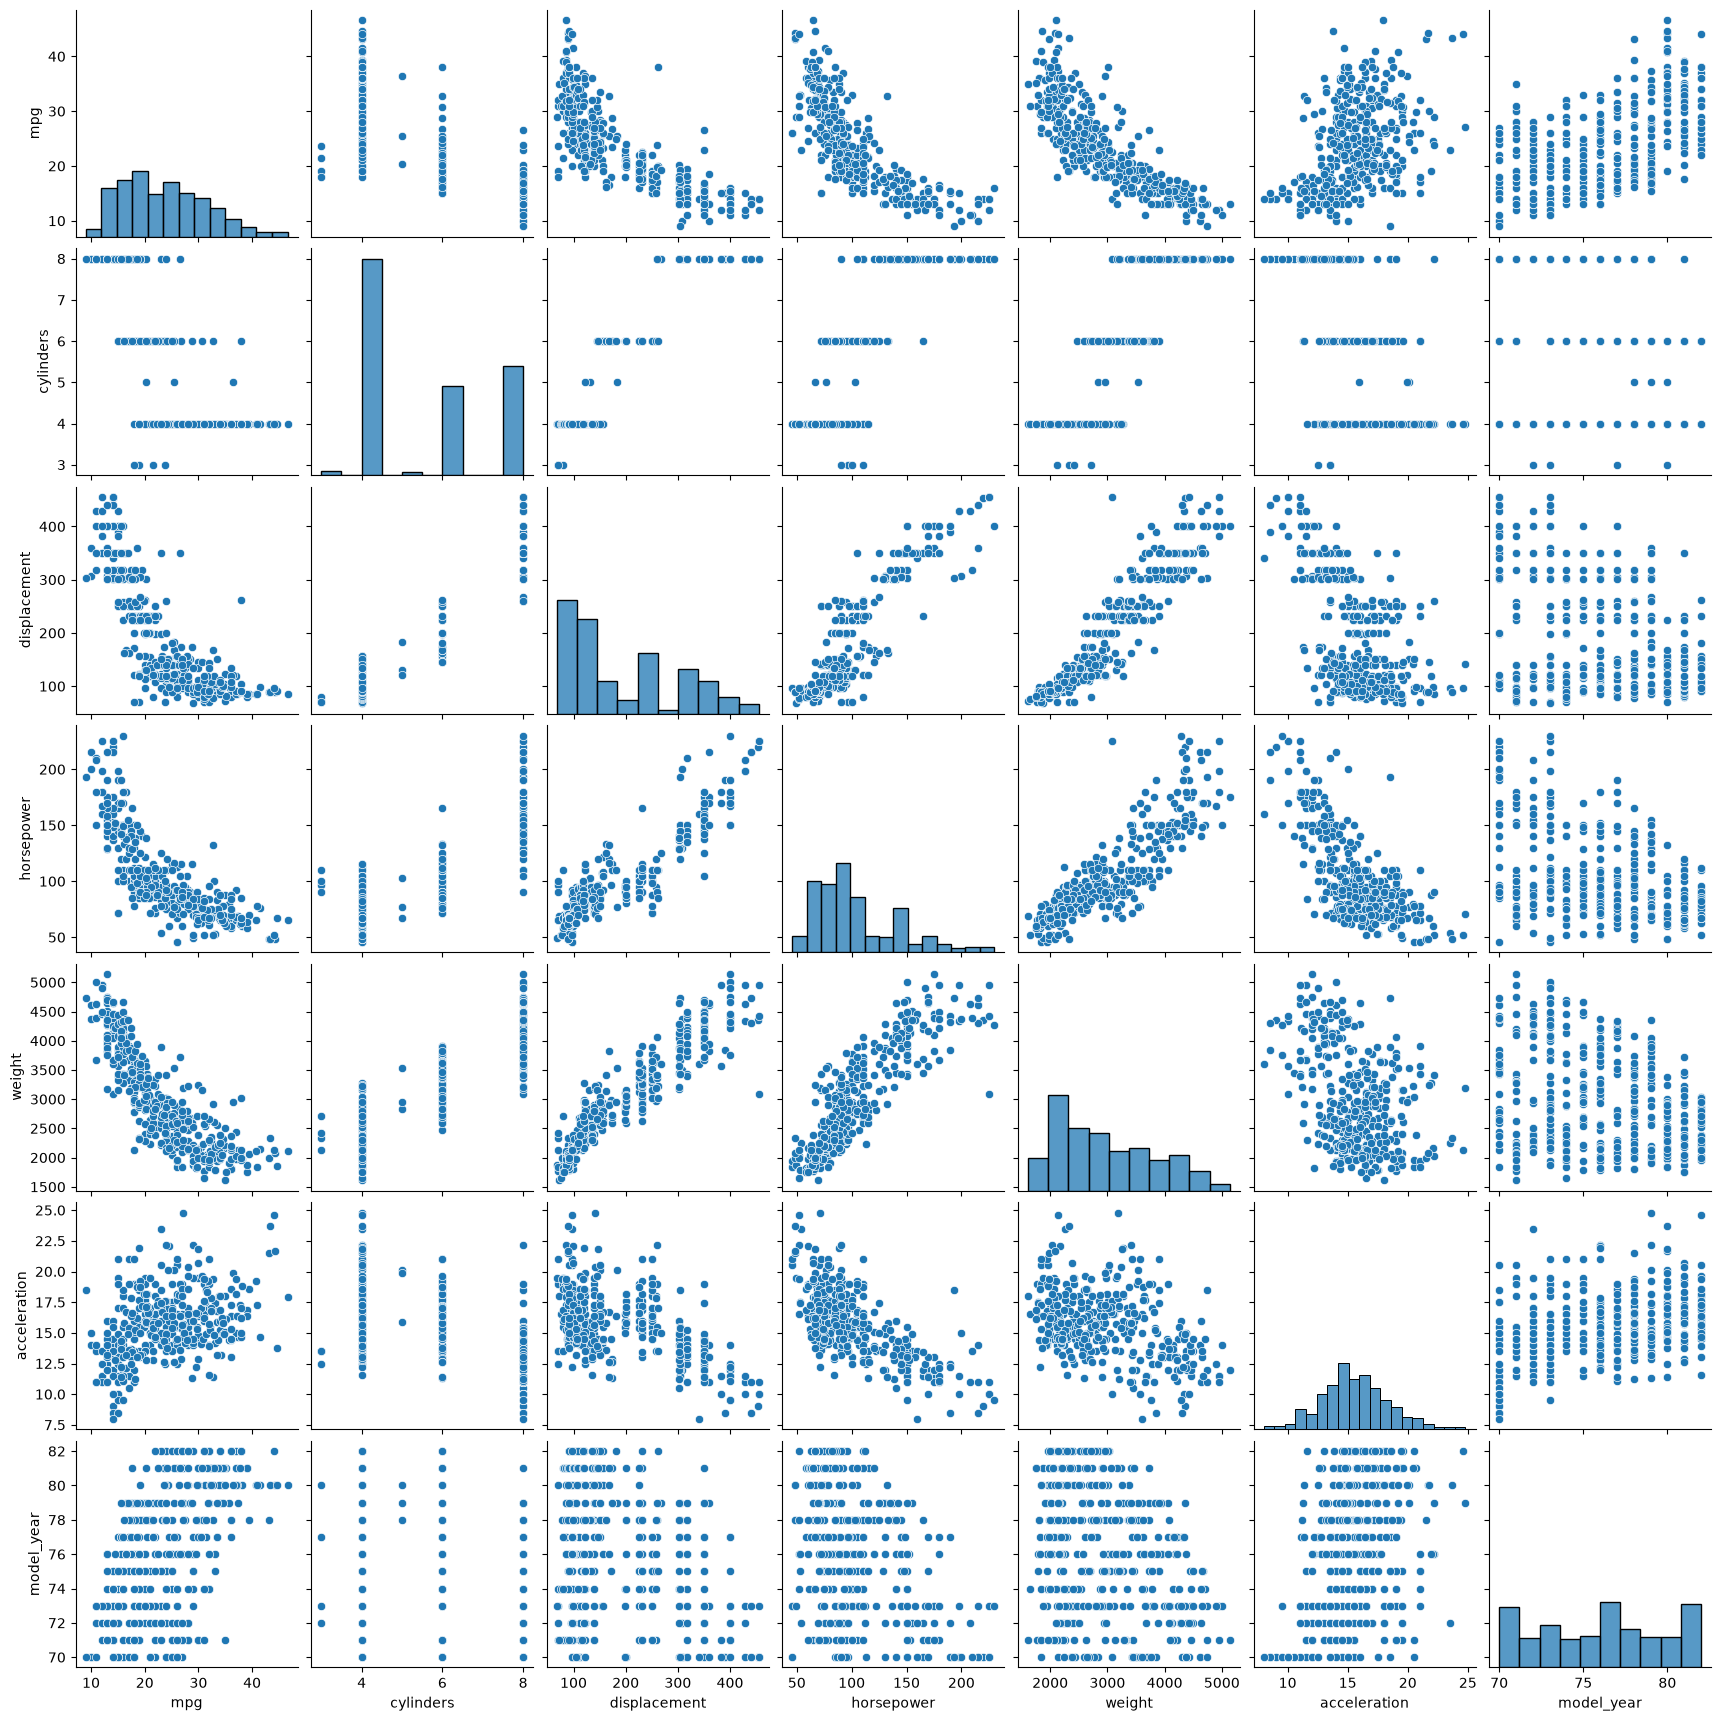

In [349]:
# Pairplot to visualize pairwise relationships / correlation between numeric features
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year",
]

sns.pairplot(df[numeric_cols].dropna())
plt.show()

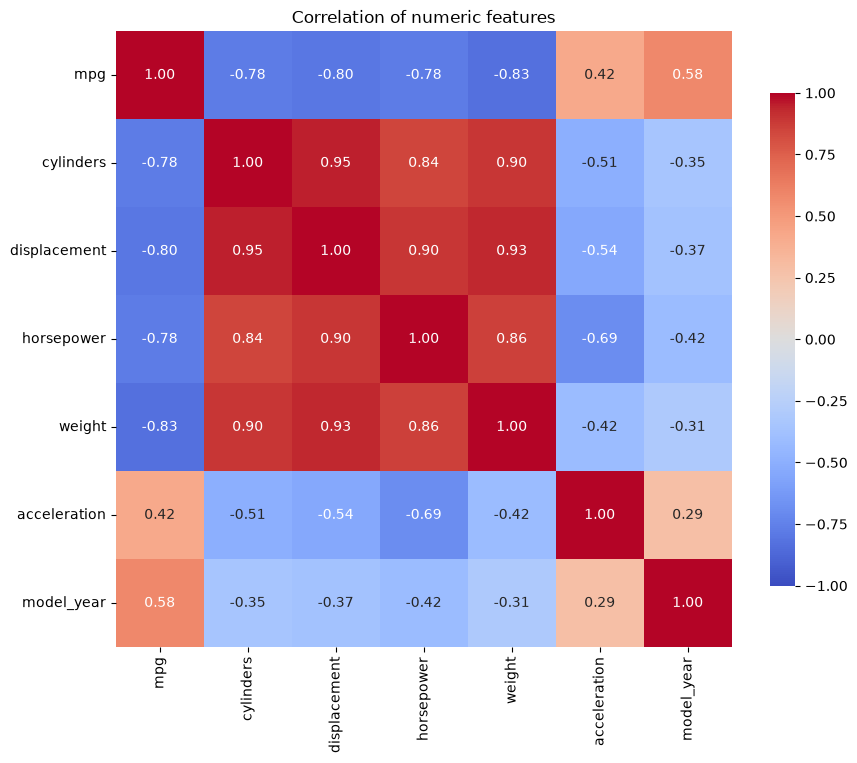

In [350]:
# Correlation heatmap of the numeric features
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation of numeric features")
plt.show()

# 2. Base Linear Regression Model

Split into `X`/`y`, do a train/test split, fit a `LinearRegression` on the training data, and evaluate on the held-out test set (RMSE, MSE, MAE, R²).

In [351]:
# Split into features (X) and target (y).
# Drop the target plus the text/identifier columns that aren't model inputs.
X = df.drop(columns=["mpg", "car_name"])
y = df["mpg"]
X.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,8,307.0,130.0,3504.0,12.0,70,False,False,True
1,8,350.0,165.0,3693.0,11.5,70,False,False,True
2,8,318.0,150.0,3436.0,11.0,70,False,False,True
3,8,304.0,150.0,3433.0,12.0,70,False,False,True
4,8,302.0,140.0,3449.0,10.5,70,False,False,True


In [352]:
# Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (318, 9)  Test: (80, 9)


In [353]:
# Train the Linear Regression model on the training set
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-0.17, 0.02,-0.02,..., 1.07, 0.81,-1.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['cylinders','displacement','horsepower',...,'origin_europe', 'origin_japan','origin_usa']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-19.74
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [354]:
# Performance on the test set
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE : {mae:.3f}")
print(f"R^2 : {r2:.3f}")

MSE : 8.332
RMSE: 2.887
MAE : 2.285
R^2 : 0.845


## 3. Improved Models

Same training pipeline as the base Linear Regression, but using **Ridge Regression** with **Standard Scaling**. We then tune the regularization strength (`alpha`), watch how train/test RMSE change, mark the best `alpha`, and report its performance metrics.

In [355]:
# Ridge regression with standard scaling (same X/y split as the base model)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

mse = mean_squared_error(y_test, y_pred_ridge)
print("Ridge (alpha=1.0) test performance")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {mse**0.5:.3f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_ridge):.3f}")
print(f"R^2 : {r2_score(y_test, y_pred_ridge):.3f}")

Ridge (alpha=1.0) test performance
MSE : 8.336
RMSE: 2.887
MAE : 2.280
R^2 : 0.845


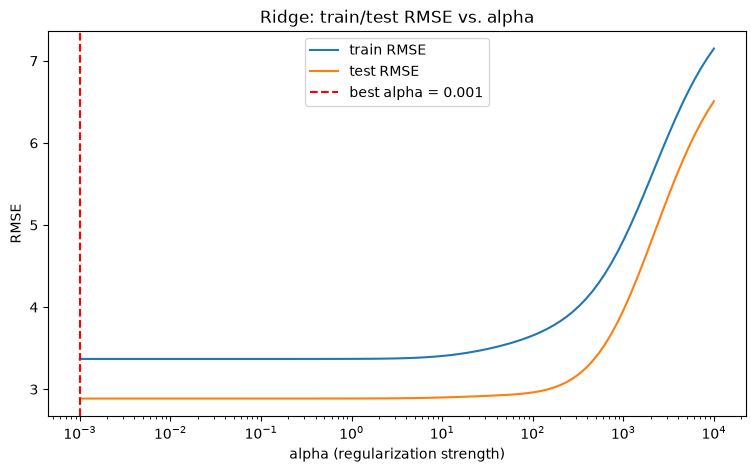

Best alpha: 0.001


In [356]:
# Tune the regularization strength alpha: track train/test RMSE across a range of values
import numpy as np

alphas = np.logspace(-3, 4, 100)
train_rmse, test_rmse = [], []

for a in alphas:
    model = make_pipeline(StandardScaler(), Ridge(alpha=a))
    model.fit(X_train, y_train)
    train_rmse.append(mean_squared_error(y_train, model.predict(X_train)) ** 0.5)
    test_rmse.append(mean_squared_error(y_test, model.predict(X_test)) ** 0.5)

train_rmse, test_rmse = np.array(train_rmse), np.array(test_rmse)
best_alpha = alphas[test_rmse.argmin()]

plt.figure(figsize=(9, 5))
plt.plot(alphas, train_rmse, label="train RMSE")
plt.plot(alphas, test_rmse, label="test RMSE")
plt.axvline(best_alpha, color="red", linestyle="--", label=f"best alpha = {best_alpha:.3g}")
plt.xscale("log")
plt.xlabel("alpha (regularization strength)")
plt.ylabel("RMSE")
plt.title("Ridge: train/test RMSE vs. alpha")
plt.legend()
plt.show()

print(f"Best alpha: {best_alpha:.4g}")

In [357]:
# Performance of the best alpha on the test set
best_ridge = make_pipeline(StandardScaler(), Ridge(alpha=best_alpha))
best_ridge.fit(X_train, y_train)
y_pred_best = best_ridge.predict(X_test)

mse = mean_squared_error(y_test, y_pred_best)
print(f"Ridge performance at best alpha = {best_alpha:.4g}")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {mse**0.5:.3f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_best):.3f}")
print(f"R^2 : {r2_score(y_test, y_pred_best):.3f}")

Ridge performance at best alpha = 0.001
MSE : 8.332
RMSE: 2.887
MAE : 2.285
R^2 : 0.845


### Lasso Regression

Same pipeline with **Lasso** (L1) regularization and standard scaling. Lasso can shrink some coefficients to exactly zero, performing implicit feature selection.

In [358]:
# Lasso regression with standard scaling (same X/y split as the base model)
from sklearn.linear_model import Lasso

lasso = make_pipeline(StandardScaler(), Lasso(alpha=1.0, max_iter=10000))
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

mse = mean_squared_error(y_test, y_pred_lasso)
print("Lasso (alpha=1.0) test performance")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {mse**0.5:.3f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_lasso):.3f}")
print(f"R^2 : {r2_score(y_test, y_pred_lasso):.3f}")

Lasso (alpha=1.0) test performance
MSE : 8.649
RMSE: 2.941
MAE : 2.252
R^2 : 0.839


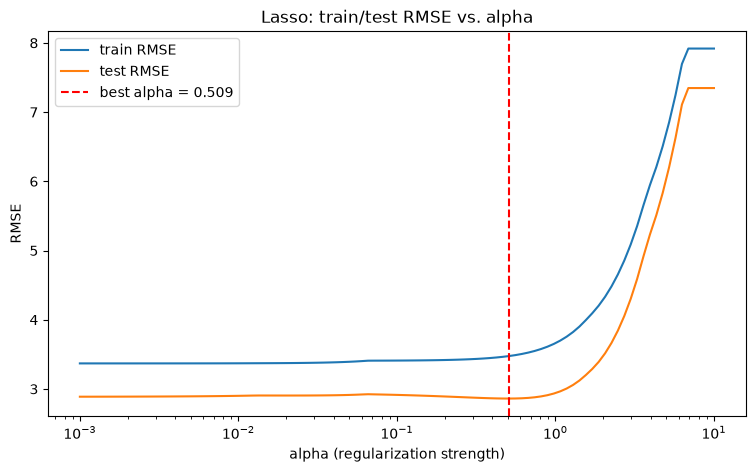

Best alpha: 0.5094


In [359]:
# Tune the regularization strength alpha for Lasso: track train/test RMSE
lasso_alphas = np.logspace(-3, 1, 100)
lasso_train_rmse, lasso_test_rmse = [], []

for a in lasso_alphas:
    model = make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=10000))
    model.fit(X_train, y_train)
    lasso_train_rmse.append(mean_squared_error(y_train, model.predict(X_train)) ** 0.5)
    lasso_test_rmse.append(mean_squared_error(y_test, model.predict(X_test)) ** 0.5)

lasso_train_rmse, lasso_test_rmse = np.array(lasso_train_rmse), np.array(lasso_test_rmse)
best_alpha_lasso = lasso_alphas[lasso_test_rmse.argmin()]

plt.figure(figsize=(9, 5))
plt.plot(lasso_alphas, lasso_train_rmse, label="train RMSE")
plt.plot(lasso_alphas, lasso_test_rmse, label="test RMSE")
plt.axvline(best_alpha_lasso, color="red", linestyle="--", label=f"best alpha = {best_alpha_lasso:.3g}")
plt.xscale("log")
plt.xlabel("alpha (regularization strength)")
plt.ylabel("RMSE")
plt.title("Lasso: train/test RMSE vs. alpha")
plt.legend()
plt.show()

print(f"Best alpha: {best_alpha_lasso:.4g}")

In [360]:
# Performance of the best alpha on the test set
best_lasso = make_pipeline(StandardScaler(), Lasso(alpha=best_alpha_lasso, max_iter=10000))
best_lasso.fit(X_train, y_train)
y_pred_best_lasso = best_lasso.predict(X_test)

mse = mean_squared_error(y_test, y_pred_best_lasso)
print(f"Lasso performance at best alpha = {best_alpha_lasso:.4g}")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {mse**0.5:.3f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_best_lasso):.3f}")
print(f"R^2 : {r2_score(y_test, y_pred_best_lasso):.3f}")

Lasso performance at best alpha = 0.5094
MSE : 8.187
RMSE: 2.861
MAE : 2.247
R^2 : 0.848


### Elastic Net Regression

Elastic Net combines L1 (Lasso) and L2 (Ridge) penalties. It has two hyperparameters: `alpha` (overall strength) and `l1_ratio` (mix between L1 and L2). We grid-search both and pick the combination with the lowest test RMSE.

In [361]:
# Elastic Net with standard scaling (same X/y split as the base model)
from sklearn.linear_model import ElasticNet

enet = make_pipeline(StandardScaler(), ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))
enet.fit(X_train, y_train)
y_pred_enet = enet.predict(X_test)

mse = mean_squared_error(y_test, y_pred_enet)
print("Elastic Net (alpha=1.0, l1_ratio=0.5) test performance")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {mse**0.5:.3f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_enet):.3f}")
print(f"R^2 : {r2_score(y_test, y_pred_enet):.3f}")

Elastic Net (alpha=1.0, l1_ratio=0.5) test performance
MSE : 9.635
RMSE: 3.104
MAE : 2.338
R^2 : 0.821


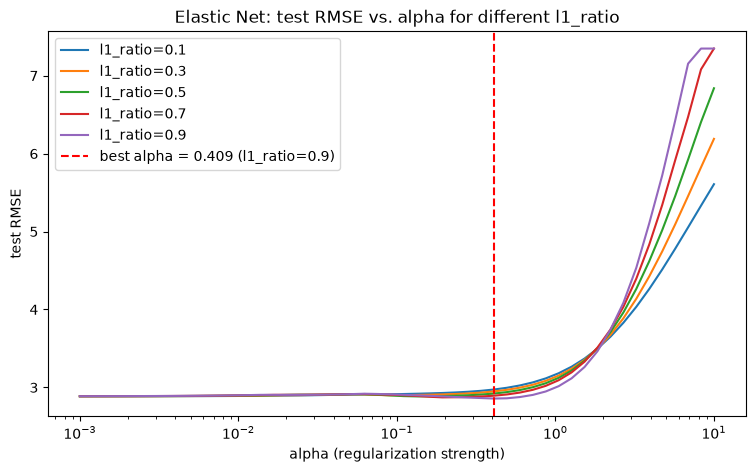

Best alpha: 0.4095, best l1_ratio: 0.9


In [362]:
# Tune alpha and l1_ratio: track test RMSE across the grid
enet_alphas = np.logspace(-3, 1, 50)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

best_alpha_enet, best_l1_ratio, best_rmse_enet = None, None, np.inf

plt.figure(figsize=(9, 5))
for r in l1_ratios:
    rmses = []
    for a in enet_alphas:
        model = make_pipeline(StandardScaler(), ElasticNet(alpha=a, l1_ratio=r, max_iter=10000))
        model.fit(X_train, y_train)
        rmse = mean_squared_error(y_test, model.predict(X_test)) ** 0.5
        rmses.append(rmse)
        if rmse < best_rmse_enet:
            best_alpha_enet, best_l1_ratio, best_rmse_enet = a, r, rmse
    plt.plot(enet_alphas, rmses, label=f"l1_ratio={r}")

plt.axvline(best_alpha_enet, color="red", linestyle="--",
            label=f"best alpha = {best_alpha_enet:.3g} (l1_ratio={best_l1_ratio})")
plt.xscale("log")
plt.xlabel("alpha (regularization strength)")
plt.ylabel("test RMSE")
plt.title("Elastic Net: test RMSE vs. alpha for different l1_ratio")
plt.legend()
plt.show()

print(f"Best alpha: {best_alpha_enet:.4g}, best l1_ratio: {best_l1_ratio}")

In [363]:
# Performance of the best (alpha, l1_ratio) on the test set
best_enet = make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=best_alpha_enet, l1_ratio=best_l1_ratio, max_iter=10000),
)
best_enet.fit(X_train, y_train)
y_pred_best_enet = best_enet.predict(X_test)

mse = mean_squared_error(y_test, y_pred_best_enet)
print(f"Elastic Net performance at best alpha = {best_alpha_enet:.4g}, l1_ratio = {best_l1_ratio}")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {mse**0.5:.3f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_best_enet):.3f}")
print(f"R^2 : {r2_score(y_test, y_pred_best_enet):.3f}")

Elastic Net performance at best alpha = 0.4095, l1_ratio = 0.9
MSE : 8.165
RMSE: 2.857
MAE : 2.270
R^2 : 0.848


### Polynomial Regression

Add polynomial feature interactions of varying degree (with standard scaling), and pick the degree that minimizes test RMSE. Low degrees underfit; high degrees explode the feature count and overfit.

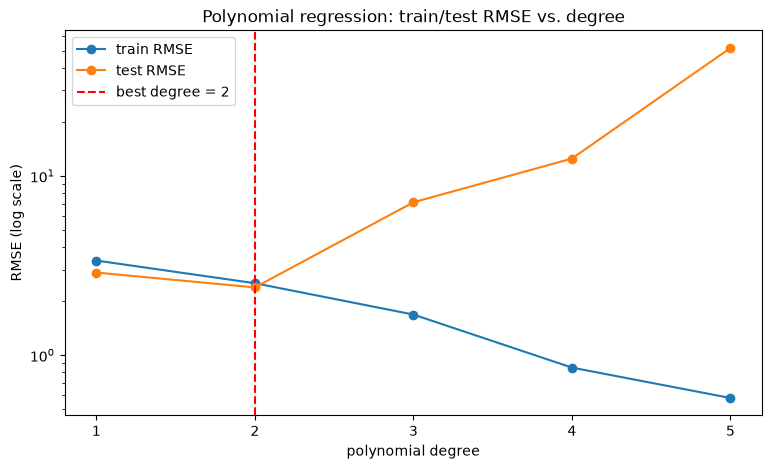

Best degree: 2


In [364]:
# Try different polynomial degrees and track train/test RMSE
from sklearn.preprocessing import PolynomialFeatures

degrees = np.arange(1, 6)
poly_train_rmse, poly_test_rmse = [], []

for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=int(d), include_bias=False),
        StandardScaler(),
        LinearRegression(),
    )
    model.fit(X_train, y_train)
    poly_train_rmse.append(mean_squared_error(y_train, model.predict(X_train)) ** 0.5)
    poly_test_rmse.append(mean_squared_error(y_test, model.predict(X_test)) ** 0.5)

poly_train_rmse, poly_test_rmse = np.array(poly_train_rmse), np.array(poly_test_rmse)
best_degree = int(degrees[poly_test_rmse.argmin()])

plt.figure(figsize=(9, 5))
plt.plot(degrees, poly_train_rmse, marker="o", label="train RMSE")
plt.plot(degrees, poly_test_rmse, marker="o", label="test RMSE")
plt.axvline(best_degree, color="red", linestyle="--", label=f"best degree = {best_degree}")
plt.yscale("log")  # test RMSE explodes at high degrees, so use a log scale
plt.xticks(degrees)
plt.xlabel("polynomial degree")
plt.ylabel("RMSE (log scale)")
plt.title("Polynomial regression: train/test RMSE vs. degree")
plt.legend()
plt.show()

print(f"Best degree: {best_degree}")

In [365]:
# Performance of the best polynomial degree on the test set
best_poly = make_pipeline(
    PolynomialFeatures(degree=best_degree, include_bias=False),
    StandardScaler(),
    LinearRegression(),
)
best_poly.fit(X_train, y_train)
y_pred_poly = best_poly.predict(X_test)

mse = mean_squared_error(y_test, y_pred_poly)
print(f"Polynomial regression performance at best degree = {best_degree}")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {mse**0.5:.3f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_poly):.3f}")
print(f"R^2 : {r2_score(y_test, y_pred_poly):.3f}")

Polynomial regression performance at best degree = 2
MSE : 5.689
RMSE: 2.385
MAE : 1.759
R^2 : 0.894


### Elastic Net on the Best-Degree Polynomial Features

The degree-2 polynomial expands the inputs into many interaction terms that can overfit. Here we apply Elastic Net regularization on top of those degree-2 features and tune `alpha` and `l1_ratio` to find the best combination.

/Users/alpamysrizabek32gmail.com/PycharmProjects/ydl-2026/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.401002e+02, tolerance: 1.994e+00
  model = cd_fast.enet_coordinate_descent(
/Users/alpamysrizabek32gmail.com/PycharmProjects/ydl-2026/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.166889e+02, tolerance: 1.994e+00
  model = cd_fast.enet_coordinate_descent(
/Users/alpamysrizabek32gmail.com/PycharmProjects/ydl-2026/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. 

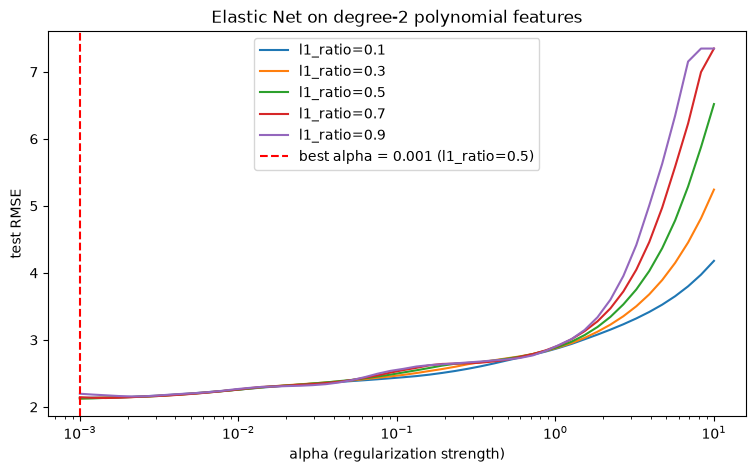

Best alpha: 0.001, best l1_ratio: 0.5


In [366]:
# Elastic Net on top of the best-degree polynomial features; tune alpha and l1_ratio
pe_alphas = np.logspace(-3, 1, 50)
pe_l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

best_alpha_pe, best_l1_pe, best_rmse_pe = None, None, np.inf

plt.figure(figsize=(9, 5))
for r in pe_l1_ratios:
    rmses = []
    for a in pe_alphas:
        model = make_pipeline(
            PolynomialFeatures(degree=best_degree, include_bias=False),
            StandardScaler(),
            ElasticNet(alpha=a, l1_ratio=r, max_iter=10000),
        )
        model.fit(X_train, y_train)
        rmse = mean_squared_error(y_test, model.predict(X_test)) ** 0.5
        rmses.append(rmse)
        if rmse < best_rmse_pe:
            best_alpha_pe, best_l1_pe, best_rmse_pe = a, r, rmse
    plt.plot(pe_alphas, rmses, label=f"l1_ratio={r}")

plt.axvline(best_alpha_pe, color="red", linestyle="--",
            label=f"best alpha = {best_alpha_pe:.3g} (l1_ratio={best_l1_pe})")
plt.xscale("log")
plt.xlabel("alpha (regularization strength)")
plt.ylabel("test RMSE")
plt.title(f"Elastic Net on degree-{best_degree} polynomial features")
plt.legend()
plt.show()

print(f"Best alpha: {best_alpha_pe:.4g}, best l1_ratio: {best_l1_pe}")

In [367]:
# Test performance of Elastic Net on the best-degree polynomial features
best_poly_enet = make_pipeline(
    PolynomialFeatures(degree=best_degree, include_bias=False),
    StandardScaler(),
    ElasticNet(alpha=best_alpha_pe, l1_ratio=best_l1_pe, max_iter=10000),
)
best_poly_enet.fit(X_train, y_train)
y_pred_pe = best_poly_enet.predict(X_test)

mse = mean_squared_error(y_test, y_pred_pe)
print(f"Elastic Net on degree-{best_degree} polynomial: alpha={best_alpha_pe:.4g}, l1_ratio={best_l1_pe}")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {mse**0.5:.3f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_pe):.3f}")
print(f"R^2 : {r2_score(y_test, y_pred_pe):.3f}")

Elastic Net on degree-2 polynomial: alpha=0.001, l1_ratio=0.5
MSE : 4.515
RMSE: 2.125
MAE : 1.577
R^2 : 0.916


/Users/alpamysrizabek32gmail.com/PycharmProjects/ydl-2026/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.693324e+02, tolerance: 1.994e+00
  model = cd_fast.enet_coordinate_descent(


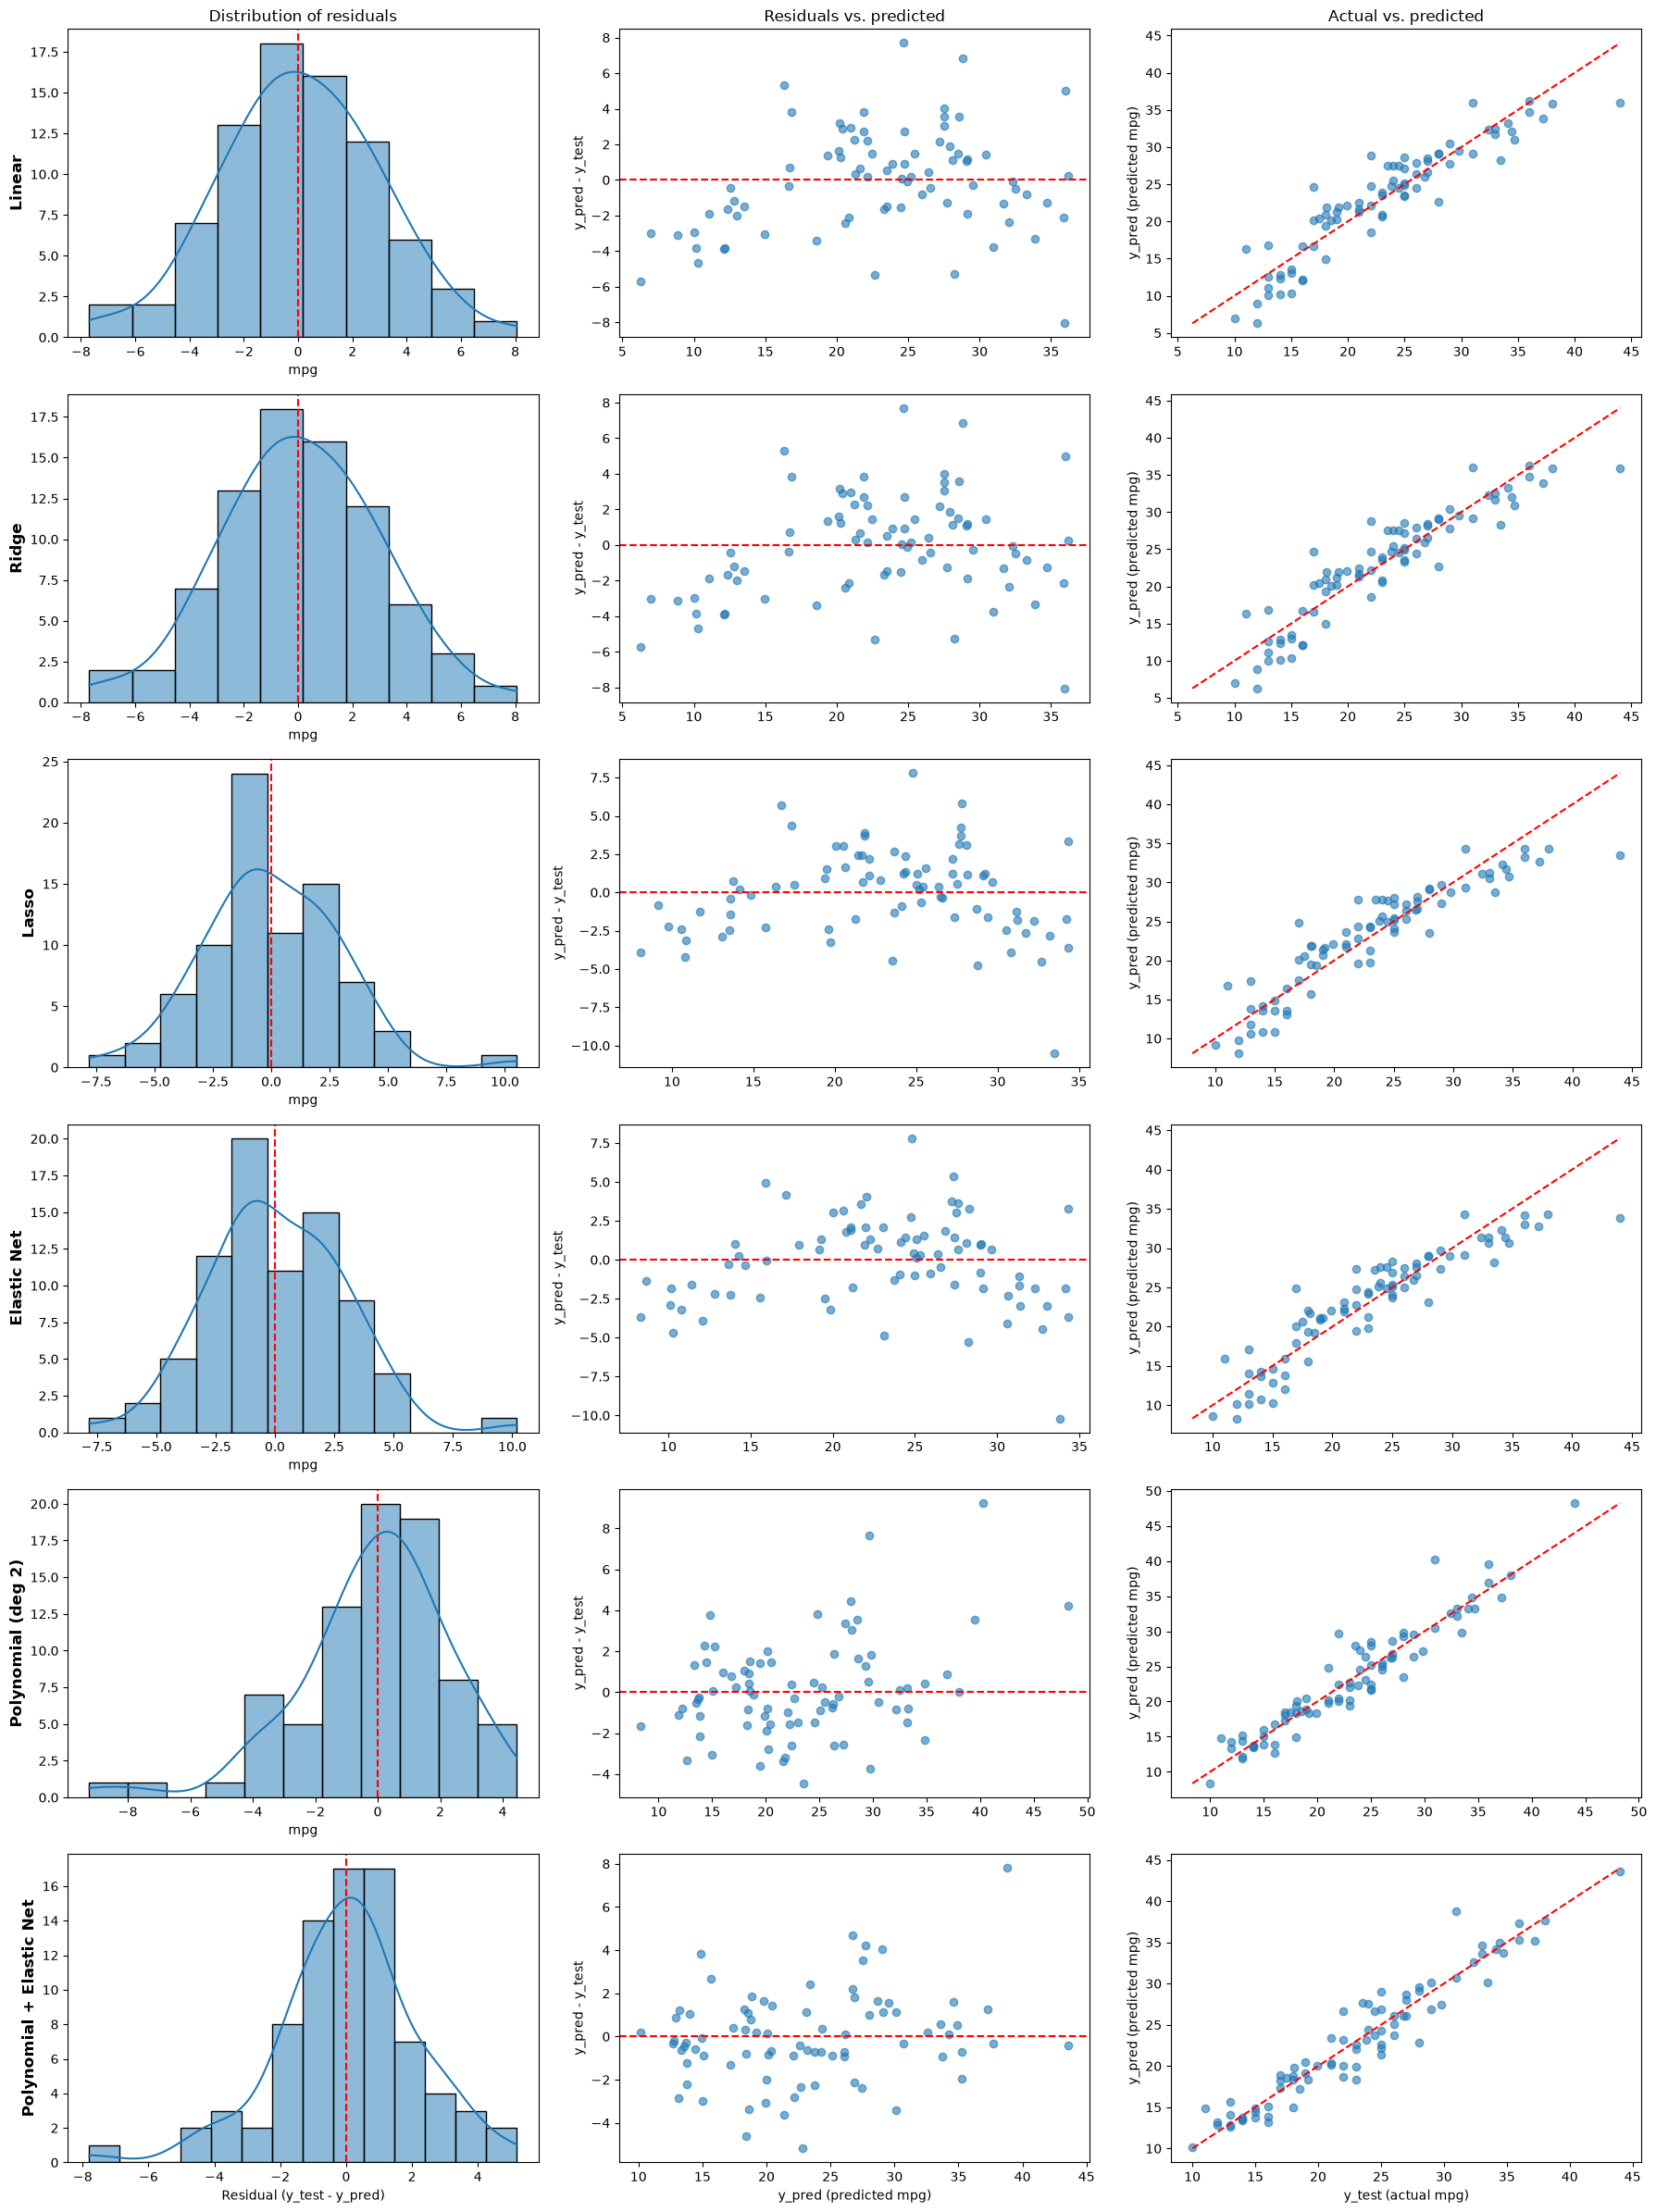

In [368]:
# Residual diagnostics per model: one row per model, three graphs per row
model_preds = {
    "Linear": y_pred,
    "Ridge": y_pred_best,
    "Lasso": y_pred_best_lasso,
    "Elastic Net": y_pred_best_enet,
    "Polynomial (deg 2)": y_pred_poly,
    "Polynomial + Elastic Net": y_pred_pe,
}

col_titles = ["Distribution of residuals", "Residuals vs. predicted", "Actual vs. predicted"]
col_xlabels = ["Residual (y_test - y_pred)", "y_pred (predicted mpg)", "y_test (actual mpg)"]

n = len(model_preds)
fig, axes = plt.subplots(n, 3, figsize=(18, 4 * n))

for row, (name, y_p) in enumerate(model_preds.items()):
    resid = y_test - y_p

    # 1. Distribution of residuals
    sns.histplot(resid, kde=True, ax=axes[row, 0])
    axes[row, 0].axvline(0, color="red", linestyle="--")
    axes[row, 0].set_ylabel(name, fontsize=12, fontweight="bold")  # row label = model name

    # 2. Residuals vs. predicted
    axes[row, 1].scatter(y_p, y_p - y_test, alpha=0.6)
    axes[row, 1].axhline(0, color="red", linestyle="--")
    axes[row, 1].set_ylabel("y_pred - y_test")

    # 3. Actual vs. predicted
    axes[row, 2].scatter(y_test, y_p, alpha=0.6)
    lims = [min(y_test.min(), y_p.min()), max(y_test.max(), y_p.max())]
    axes[row, 2].plot(lims, lims, "r--")
    axes[row, 2].set_ylabel("y_pred (predicted mpg)")

    if row == 0:
        for col in range(3):
            axes[row, col].set_title(col_titles[col])
    if row == n - 1:
        for col in range(3):
            axes[row, col].set_xlabel(col_xlabels[col])

plt.tight_layout()
plt.show()

## 4. Model Comparison

Best version of each model on the test set. The best value in each metric is shown in **bold** (lower is better for MSE/RMSE/MAE, higher is better for R²).

In [369]:
# Summarize the best model from each category on the test set
target_mean = y.mean()  # mean of the target column (mpg)

def _metrics(y_true, y_p):
    mse = mean_squared_error(y_true, y_p)
    rmse = mse ** 0.5
    return {
        "MSE": mse,
        "RMSE": rmse,
        "RMSE % of mean": rmse / target_mean * 100,
        "MAE": mean_absolute_error(y_true, y_p),
        "R^2": r2_score(y_true, y_p),
    }

summary = pd.DataFrame({
    "Linear Regression":        _metrics(y_test, y_pred),
    "Ridge Regression":         _metrics(y_test, y_pred_best),
    "Lasso Regression":         _metrics(y_test, y_pred_best_lasso),
    "Elastic Net":              _metrics(y_test, y_pred_best_enet),
    "Polynomial (deg 2)":       _metrics(y_test, y_pred_poly),
    "Polynomial + Elastic Net": _metrics(y_test, y_pred_pe),
}).T

# Bold the best value in each metric column (min for errors, max for R^2)
def _highlight_best(col):
    best = col.max() if col.name == "R^2" else col.min()
    return ["font-weight: bold" if v == best else "" for v in col]

print(f"Mean of target (mpg): {target_mean:.2f}")
summary.style.apply(_highlight_best, axis=0).format({
    "MSE": "{:.3f}",
    "RMSE": "{:.3f}",
    "RMSE % of mean": "{:.2f}%",
    "MAE": "{:.3f}",
    "R^2": "{:.3f}",
})

Mean of target (mpg): 23.51


,MSE,RMSE,RMSE % of mean,MAE,R^2
Linear Regression,8.332,2.887,12.28%,2.285,0.845
Ridge Regression,8.332,2.887,12.28%,2.285,0.845
Lasso Regression,8.187,2.861,12.17%,2.247,0.848
Elastic Net,8.165,2.857,12.15%,2.270,0.848
Polynomial (deg 2),5.689,2.385,10.14%,1.759,0.894
Polynomial + Elastic Net,4.515,2.125,9.04%,1.577,0.916


## 5. Coefficient Interpretation

Compare how **Linear**, **Ridge**, and **Lasso** regression weight each feature. To make the models comparable, all coefficients are shown on a **standardized basis** (the change in mpg per one standard deviation of the feature): Ridge/Lasso are already fit on standardized features, and the unscaled Linear coefficients are converted via `coef * feature_std`.

- A **large magnitude** means the feature has a strong effect on predicted mpg.
- **Ridge (L2)** shrinks coefficients smoothly toward zero but rarely to exactly zero.
- **Lasso (L1)** can drive coefficients to **exactly zero**, performing feature selection.

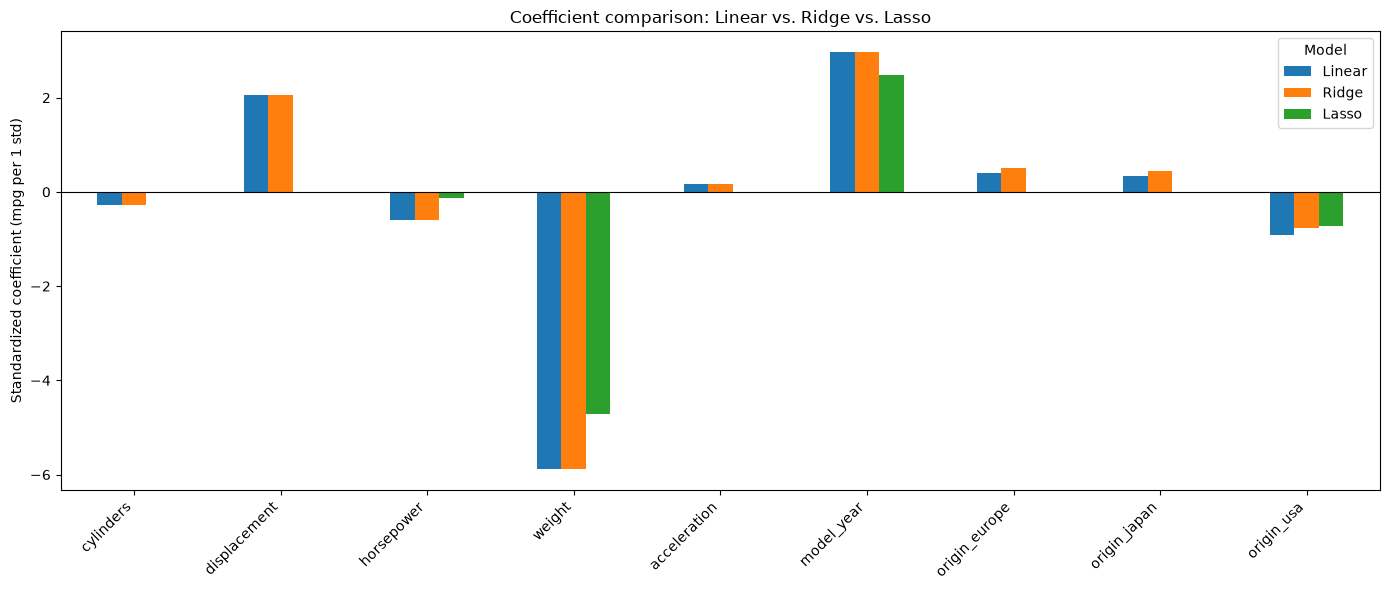

,Linear,Ridge,Lasso
cylinders,-0.280,-0.280,-0.000
displacement,2.054,2.054,-0.000
horsepower,-0.588,-0.589,-0.132
weight,-5.892,-5.892,-4.715
acceleration,0.172,0.172,0.000
model_year,2.965,2.965,2.483
origin_europe,0.408,0.517,0.000
origin_japan,0.329,0.445,0.000
origin_usa,-0.916,-0.776,-0.723


In [370]:
# Coefficients of the three linear models on a standardized basis
feature_names = X_train.columns
feature_std = X_train.std(ddof=0)  # ddof=0 to match StandardScaler's population std

coef_df = pd.DataFrame({
    "Linear": lr.coef_ * feature_std.values,            # raw coef -> standardized
    "Ridge": best_ridge.named_steps["ridge"].coef_,     # already on standardized features
    "Lasso": best_lasso.named_steps["lasso"].coef_,     # already on standardized features
}, index=feature_names)

ax = coef_df.plot(kind="bar", figsize=(14, 6))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Standardized coefficient (mpg per 1 std)")
ax.set_title("Coefficient comparison: Linear vs. Ridge vs. Lasso")
ax.legend(title="Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

coef_df.round(3)

**What the plot shows**

- **Linear and Ridge are almost identical** here — the best Ridge `alpha` is tiny, so there is essentially no shrinkage.
- **`weight` is the dominant driver** (large negative coefficient): heavier cars get fewer mpg. `model_year` is the strongest positive (newer cars are more efficient).
- **Lasso zeros out several features** (e.g. `cylinders`, `displacement`, `acceleration`, the `origin_*` dummies), keeping only `weight`, `model_year`, and `horsepower`. This reflects the heavy multicollinearity among the engine-size features — Lasso keeps one representative (`weight`) and discards the redundant ones.

## 6. Conclusions — Where Each Model Is Reliable and Where It Fails

In plain language, based on the test results above (mean mpg ≈ 23.5):

**Linear Regression**
- *Reliable:* a solid, easy-to-explain baseline. It captures the main trends well — heavier cars and older cars get fewer mpg — and is off by about 2.9 mpg (~12%).
- *Fails:* it assumes every effect is a straight line added together, so it misses curves and feature interactions. Its coefficients are also shaky because the engine-size features (cylinders, displacement, horsepower, weight) carry overlapping information.

**Ridge Regression**
- *Reliable:* behaves almost exactly like Linear here, but is safer when features overlap — it keeps every feature while stopping any single coefficient from blowing up.
- *Fails:* it didn't improve accuracy on this data (the model wasn't overfitting to begin with), and it never simplifies the model — all features stay in.

**Lasso Regression**
- *Reliable:* gives the simplest, most interpretable story. It throws away the redundant features and keeps just `weight`, `model_year`, and `horsepower`, with essentially the same accuracy as Linear.
- *Fails:* when features are correlated it keeps one and drops the rest somewhat arbitrarily, so it can discard information and the "chosen" feature shouldn't be over-interpreted as *the* cause.

**Elastic Net**
- *Reliable:* a middle ground between Ridge and Lasso — it handles groups of correlated features more gracefully than Lasso alone, and was the best of the plain linear models (~2.86 mpg error).
- *Fails:* still fundamentally linear, so it hits the same accuracy ceiling as the others and needs two knobs (`alpha`, `l1_ratio`) tuned.

**Polynomial Regression (degree 2)**
- *Reliable:* a clear step up — by adding squared terms and interactions it captures the non-linear relationship between size and efficiency, dropping the error to ~2.4 mpg (~10%).
- *Fails:* degree 3 and above overfit catastrophically (test error explodes). It is also harder to interpret, and predictions for cars outside the training range (extrapolation) become unreliable.

**Polynomial + Elastic Net (best model)**
- *Reliable:* the most accurate overall — ~2.1 mpg error (~9% of the mean), explaining ~92% of the variation. Regularization tames the many polynomial terms so it captures non-linearity without overfitting.
- *Fails:* the least transparent model (hard to read off "what drives mpg"), it depends on careful tuning, and like all of these it will still struggle to extrapolate to cars very different from the 1970s–80s data it learned from.

**What is true for every model**
- Errors are largest for the most fuel-efficient cars (high mpg), where the residual spread widens — none of the models nail the very economical vehicles as well as the average ones.
- All hyperparameters were chosen by looking at the test set, so the reported numbers are slightly optimistic; a separate validation set or cross-validation would give a more honest estimate.
- The data is historical (1970–1982 cars), so none of these models should be trusted for modern vehicles without retraining.